# Concentration Regression from QD Photoluminescence Spectra

Predicts dopant concentration (log₁₀ molar) from PL spectra using SVD + regression.  
Separate models per compound type: **Fe (FeCl₃)**, **Co (CoCl₂)**, **FeCo (FeCl₃+CoCl₂)**.  
Time filter: **0 hrs only**. Concentration target: **log₁₀(molar)**.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import RidgeCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# Add project root to path so we can import svd_analysis
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from svd_analysis import SVDSpectralAnalyzer

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load and Filter Data

In [2]:
DATA_PATH = Path('final_cleaned_data.csv')

df = pd.read_csv(DATA_PATH)
print(f"Total rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")
print(f"\nCompound counts:\n{df['Compound'].value_counts()}")
print(f"\nTime values: {df['Time'].unique()}")
print(f"\nConcentration values (sample): {sorted(df['Concentration'].unique())}")

Total rows: 493,053
Columns: ['Wavelength (nm)', 'Intensity (a.u.)', 'Compound', 'Concentration', 'Time', 'Source File', 'Data_Version', 'Folder_Source']

Compound counts:
Compound
FeCl3 CoCl2    240999
CoCl2          121605
FeCl3          119394
Control         11055
Name: count, dtype: int64

Time values: ['0 hrs' '4 hrs' '2 hrs']

Concentration values (sample): ['100mM', '100uM', '10mM', '1mM', '250uM', '25mM', '2mM', '3mM', '4mM', '500uM', '50mM', '50uM', '5mM', '6mM', '75mM', '7mM', '8mM', '9mM', 'Unknown']


In [3]:
# Keep only 0 hrs and known concentrations
df_filtered = df[
    (df['Time'] == '0 hrs') &
    (df['Concentration'] != 'Unknown')
].copy()

print(f"Rows after filtering (0 hrs, known concentration): {len(df_filtered):,}")
print(f"Compound counts:\n{df_filtered['Compound'].value_counts()}")

Rows after filtering (0 hrs, known concentration): 163,614
Compound counts:
Compound
FeCl3 CoCl2    81807
CoCl2          42009
FeCl3          39798
Name: count, dtype: int64


## 2. Long → Wide Pivot + Wavelength Preprocessing

In [4]:
def parse_concentration(s: str) -> float:
    """Convert concentration string ('50uM', '10mM') to molar float."""
    s = s.strip()
    if s.endswith('uM'):
        return float(s[:-2]) * 1e-6
    elif s.endswith('mM'):
        return float(s[:-2]) * 1e-3
    elif s.endswith('M'):
        return float(s[:-1])
    raise ValueError(f"Cannot parse concentration: {s!r}")

# Parse concentrations
df_filtered['conc_molar'] = df_filtered['Concentration'].apply(parse_concentration)
df_filtered['conc_log10'] = np.log10(df_filtered['conc_molar'])

print("Concentration range:")
print(f"  min: {df_filtered['conc_molar'].min():.2e} M  (log10 = {df_filtered['conc_log10'].min():.2f})")
print(f"  max: {df_filtered['conc_molar'].max():.2e} M  (log10 = {df_filtered['conc_log10'].max():.2f})")

Concentration range:
  min: 5.00e-05 M  (log10 = -4.30)
  max: 1.00e-01 M  (log10 = -1.00)


In [5]:
WL_MIN, WL_MAX = 380.0, 880.0
N_WAVELENGTHS = 1000
TARGET_WL = np.linspace(WL_MIN, WL_MAX, N_WAVELENGTHS)

def build_spectral_matrix(df_compound: pd.DataFrame) -> tuple:
    """
    Pivot long-format DataFrame for one compound into a spectral matrix.
    Returns (X, y_log10, y_molar, group_meta) where X shape = (n_spectra, N_WAVELENGTHS).
    Groups spectra by (Source File, Concentration).
    """
    X_list, y_log_list, y_molar_list, meta_list = [], [], [], []

    groups = df_compound.groupby(['Source File', 'Concentration'])
    for (src, conc_str), grp in groups:
        # Restrict to 380–880 nm
        grp_crop = grp[
            (grp['Wavelength (nm)'] >= WL_MIN) &
            (grp['Wavelength (nm)'] <= WL_MAX)
        ].sort_values('Wavelength (nm)')

        if len(grp_crop) < 10:
            continue  # skip degenerate spectra

        wl = grp_crop['Wavelength (nm)'].values
        intensity = grp_crop['Intensity (a.u.)'].values

        # Interpolate to uniform 1000-point grid
        intensity_interp = np.interp(TARGET_WL, wl, intensity)

        conc_m = grp_crop['conc_molar'].iloc[0]
        X_list.append(intensity_interp)
        y_molar_list.append(conc_m)
        y_log_list.append(np.log10(conc_m))
        meta_list.append({'Source File': src, 'Concentration': conc_str})

    X = np.array(X_list, dtype=float)
    y_log = np.array(y_log_list, dtype=float)
    y_molar = np.array(y_molar_list, dtype=float)
    return X, y_log, y_molar, meta_list


COMPOUND_MAP = {
    'Fe':   'FeCl3',
    'Co':   'CoCl2',
    'FeCo': 'FeCl3 CoCl2',
}

datasets = {}
for label, compound in COMPOUND_MAP.items():
    df_c = df_filtered[df_filtered['Compound'] == compound]
    X, y_log, y_molar, meta = build_spectral_matrix(df_c)
    datasets[label] = {'X': X, 'y_log': y_log, 'y_molar': y_molar, 'meta': meta}
    print(f"{label:6s} ({compound}): {X.shape[0]} spectra, "
          f"conc range {y_molar.min():.2e}–{y_molar.max():.2e} M, "
          f"log10 {y_log.min():.2f}–{y_log.max():.2f}")

Fe     (FeCl3): 18 spectra, conc range 5.00e-05–1.00e-01 M, log10 -4.30–-1.00
Co     (CoCl2): 18 spectra, conc range 5.00e-05–1.00e-01 M, log10 -4.30–-1.00
FeCo   (FeCl3 CoCl2): 36 spectra, conc range 5.00e-05–1.00e-01 M, log10 -4.30–-1.00


## 3. SVD Analysis per Compound

In [6]:
N_SVD_COMPONENTS = 10  # same as classification work

def fit_svd(X: np.ndarray, n_components: int = N_SVD_COMPONENTS) -> tuple:
    """Fit SVD and return (features, analyzer)."""
    analyzer = SVDSpectralAnalyzer(X, TARGET_WL)
    analyzer.fit(center=True)
    features = analyzer.U[:, :n_components] * analyzer.S[:n_components]
    return features, analyzer


svd_results = {}
for label, ds in datasets.items():
    features, analyzer = fit_svd(ds['X'])
    svd_results[label] = {'features': features, 'analyzer': analyzer}
    var_cumsum = np.cumsum(analyzer.explained_variance_ratio)
    print(f"{label}: {N_SVD_COMPONENTS} components → {var_cumsum[N_SVD_COMPONENTS-1]*100:.2f}% variance")

Fe: 10 components → 100.00% variance
Co: 10 components → 99.70% variance
FeCo: 10 components → 99.99% variance


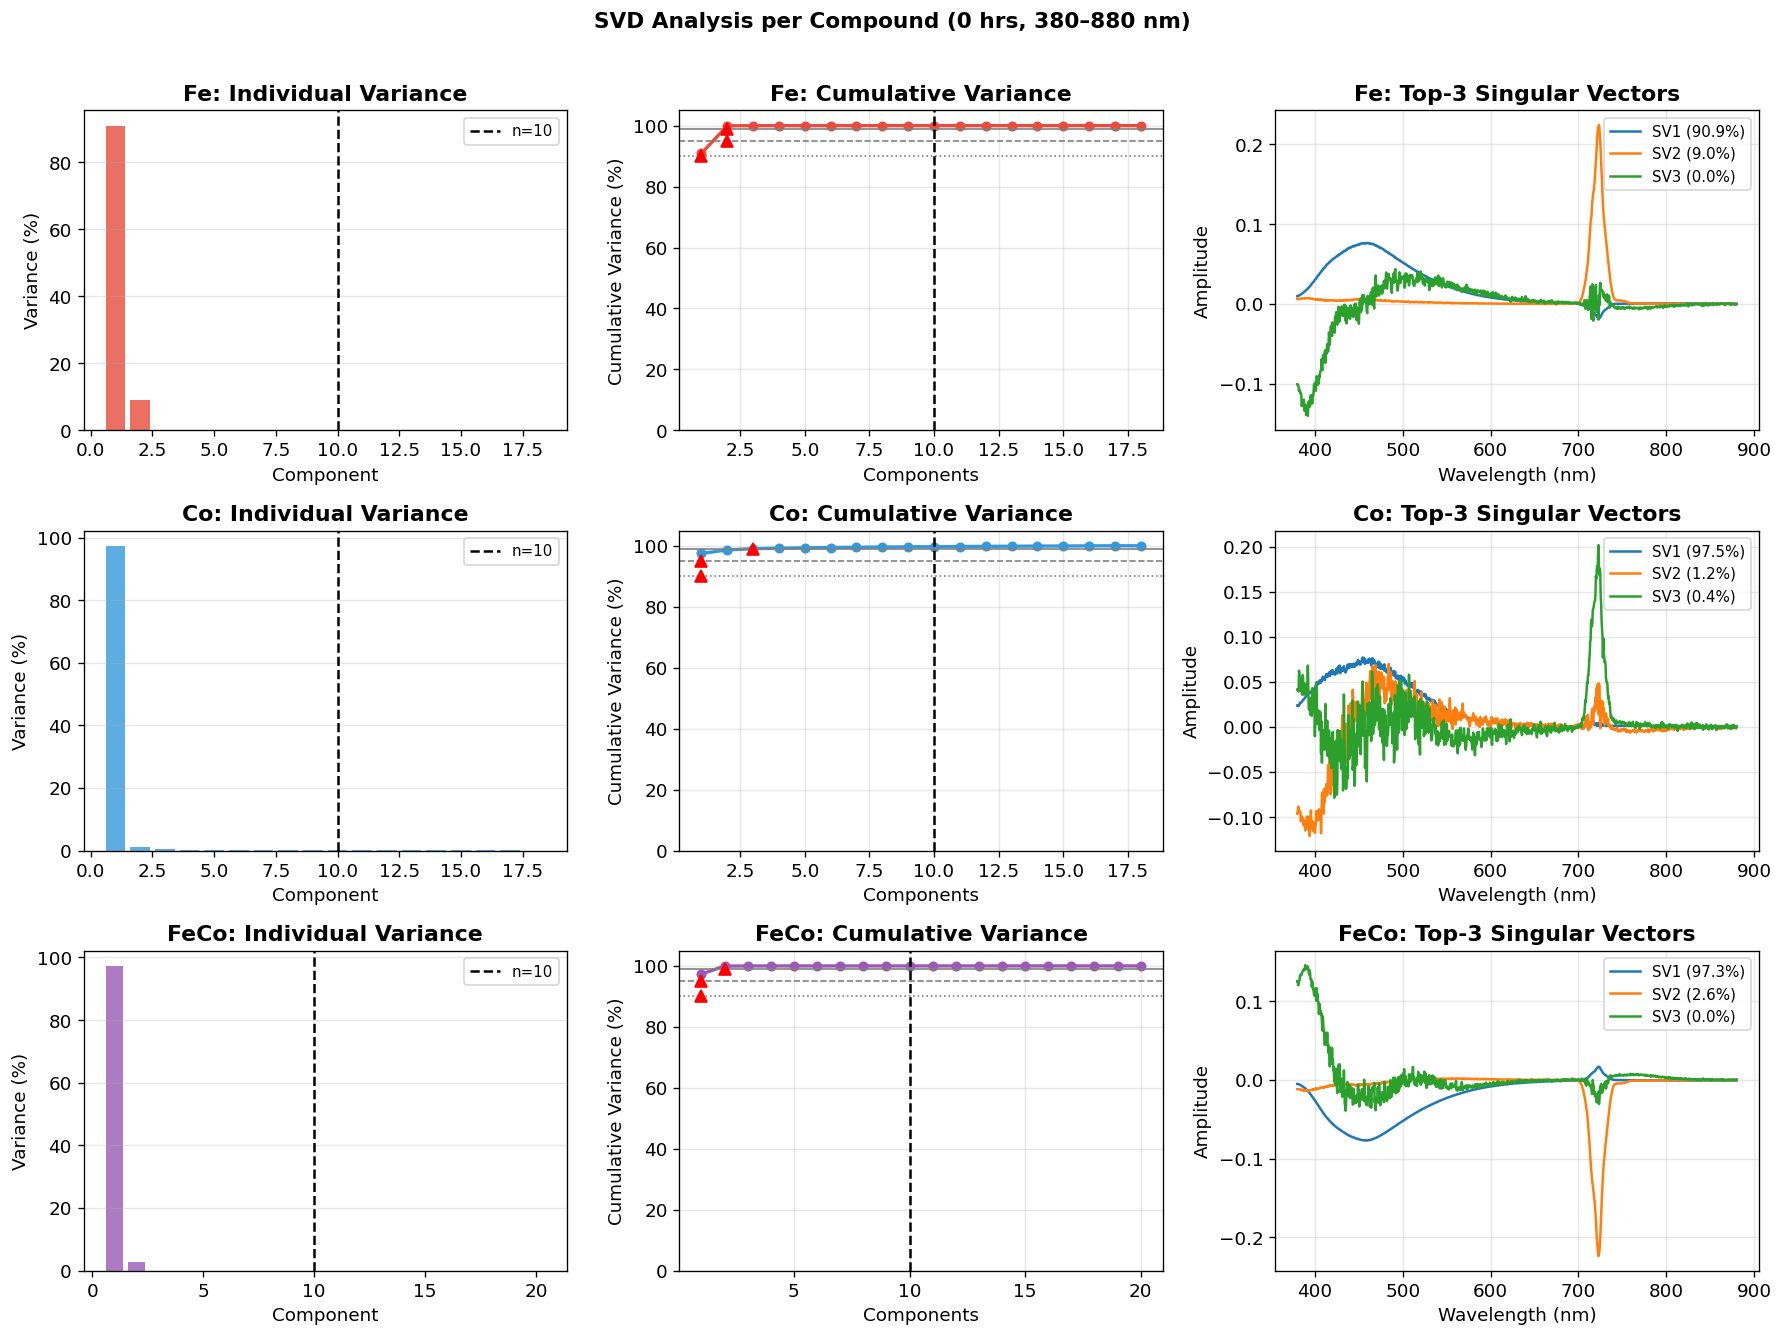

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
compound_colors = {'Fe': '#e74c3c', 'Co': '#3498db', 'FeCo': '#9b59b6'}

for row_idx, label in enumerate(['Fe', 'Co', 'FeCo']):
    analyzer = svd_results[label]['analyzer']
    evr = analyzer.explained_variance_ratio
    cumvar = np.cumsum(evr)
    color = compound_colors[label]
    n_show = min(20, len(evr))

    # Panel 1: individual variance
    ax = axes[row_idx, 0]
    ax.bar(range(1, n_show + 1), evr[:n_show] * 100, color=color, alpha=0.8)
    ax.axvline(N_SVD_COMPONENTS, color='black', linestyle='--', linewidth=1.5, label=f'n={N_SVD_COMPONENTS}')
    ax.set_xlabel('Component')
    ax.set_ylabel('Variance (%)')
    ax.set_title(f'{label}: Individual Variance', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Panel 2: cumulative variance
    ax = axes[row_idx, 1]
    ax.plot(range(1, n_show + 1), cumvar[:n_show] * 100, 'o-', color=color, linewidth=2, markersize=5)
    for thr, ls in [(0.90, ':'), (0.95, '--'), (0.99, '-')]:
        n_thr = analyzer.find_n_components_for_variance(thr)
        if n_thr <= n_show:
            ax.axhline(thr * 100, color='gray', linestyle=ls, linewidth=1)
            ax.plot(n_thr, thr * 100, 'r^', markersize=7)
    ax.axvline(N_SVD_COMPONENTS, color='black', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Components')
    ax.set_ylabel('Cumulative Variance (%)')
    ax.set_title(f'{label}: Cumulative Variance', fontweight='bold')
    ax.set_ylim([0, 105])
    ax.grid(alpha=0.3)

    # Panel 3: top-3 singular vectors (spectral basis)
    ax = axes[row_idx, 2]
    for k in range(3):
        sv = analyzer.Vt[k, :]
        ax.plot(TARGET_WL, sv, label=f'SV{k+1} ({evr[k]*100:.1f}%)', linewidth=1.5)
    ax.set_xlabel('Wavelength (nm)')
    ax.set_ylabel('Amplitude')
    ax.set_title(f'{label}: Top-3 Singular Vectors', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('SVD Analysis per Compound (0 hrs, 380–880 nm)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('svd_analysis_per_compound.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Regression Pipeline

In [8]:
def make_models():
    """Return dict of (name → unfitted model)."""
    return {
        'Ridge': RidgeCV(alphas=np.logspace(-3, 3, 20)),
        'SVR': SVR(kernel='rbf', C=10.0, epsilon=0.05),
        'XGBoost': XGBRegressor(
            n_estimators=500, learning_rate=0.1, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, verbosity=0
        ),
        'CatBoost': CatBoostRegressor(
            iterations=1000, learning_rate=0.05, depth=6,
            loss_function='RMSE', random_seed=RANDOM_STATE,
            early_stopping_rounds=50, verbose=False
        ),
    }


def cross_validate_regression(X: np.ndarray, y_log: np.ndarray, y_molar: np.ndarray,
                               n_splits: int = 5) -> dict:
    """
    Stratified CV for all 4 regressors.
    Stratification is on discrete concentration levels (rounded log10).
    n_splits is capped to the minimum number of samples in any concentration level.
    Returns dict: model_name → {r2, rmse_molar, mae_molar, y_true_all, y_pred_all}.
    """
    import copy

    # Concentrations are discrete — round log10 to 2 dp gives one label per level
    strat_labels = np.round(y_log, 2)
    unique, counts = np.unique(strat_labels, return_counts=True)
    min_count = int(counts.min())
    actual_splits = min(n_splits, min_count)
    print(f"  Concentration levels: {len(unique)}, min count per level: {min_count} "
          f"→ using {actual_splits}-fold CV")

    skf = StratifiedKFold(n_splits=actual_splits, shuffle=True, random_state=RANDOM_STATE)
    results = {}

    for model_name, model_template in make_models().items():
        fold_r2, fold_rmse, fold_mae = [], [], []
        y_true_all, y_pred_log_all = [], []

        for train_idx, val_idx in skf.split(X, strat_labels):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y_log[train_idx], y_log[val_idx]
            y_val_molar = y_molar[val_idx]

            # Scale features (always; harmless for tree models)
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_val_s = scaler.transform(X_val)

            model = copy.deepcopy(model_template)

            if model_name == 'CatBoost':
                model.fit(X_tr_s, y_tr,
                          eval_set=(X_val_s, y_val),
                          verbose=False)
            else:
                model.fit(X_tr_s, y_tr)

            y_pred_log = model.predict(X_val_s)
            y_pred_molar = 10 ** y_pred_log

            fold_r2.append(r2_score(y_val, y_pred_log))
            fold_rmse.append(np.sqrt(mean_squared_error(y_val_molar, y_pred_molar)))
            fold_mae.append(mean_absolute_error(y_val_molar, y_pred_molar))
            y_true_all.extend(y_val_molar.tolist())
            y_pred_log_all.extend(y_pred_log.tolist())

        results[model_name] = {
            'r2_folds': np.array(fold_r2),
            'rmse_folds': np.array(fold_rmse),
            'mae_folds': np.array(fold_mae),
            'r2_mean': np.mean(fold_r2),
            'r2_std': np.std(fold_r2),
            'rmse_mean': np.mean(fold_rmse),
            'rmse_std': np.std(fold_rmse),
            'mae_mean': np.mean(fold_mae),
            'mae_std': np.std(fold_mae),
            'y_true_molar': np.array(y_true_all),
            'y_pred_molar': 10 ** np.array(y_pred_log_all),
            'n_folds': actual_splits,
        }

    return results


print("Regression pipeline defined.")

Regression pipeline defined.


In [9]:
all_cv_results = {}

for label in ['Fe', 'Co', 'FeCo']:
    print(f"\n{'='*60}")
    print(f"Cross-validating: {label}")
    print(f"{'='*60}")
    X_feat = svd_results[label]['features']
    y_log = datasets[label]['y_log']
    y_molar = datasets[label]['y_molar']

    cv_res = cross_validate_regression(X_feat, y_log, y_molar)
    all_cv_results[label] = cv_res

    for model_name, res in cv_res.items():
        print(f"  {model_name:10s}: R²={res['r2_mean']:.4f}±{res['r2_std']:.4f} "
              f"RMSE={res['rmse_mean']:.4e}±{res['rmse_std']:.4e} M")


Cross-validating: Fe
  Concentration levels: 18, min count per level: 1 → using 1-fold CV


ValueError: k-fold cross-validation requires at least one train/test split by setting n_splits=2 or more, got n_splits=1.

## 5. CV Summary: R² per Model and Compound

In [ ]:
model_names = list(make_models().keys())
compound_labels = ['Fe', 'Co', 'FeCo']
colors_model = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for col_idx, label in enumerate(compound_labels):
    ax = axes[col_idx]
    x = np.arange(len(model_names))
    for i, (model_name, color) in enumerate(zip(model_names, colors_model)):
        res = all_cv_results[label][model_name]
        ax.bar(x[i], res['r2_mean'], width=0.65,
               color=color, alpha=0.85, label=model_name if col_idx == 0 else None,
               yerr=res['r2_std'], capsize=4, error_kw={'linewidth': 1.5})

    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=15, ha='right')
    ax.set_title(f'{label}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Mean CV R²' if col_idx == 0 else '')
    ax.set_ylim([0, 1.05])
    ax.axhline(1.0, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
    ax.grid(axis='y', alpha=0.3)

axes[0].legend(loc='lower right', fontsize=9)
plt.suptitle('5-Fold CV R² per Model and Compound (SVD features, log₁₀ target)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cv_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Predicted vs Actual Plots (Best Model per Compound)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col_idx, label in enumerate(compound_labels):
    # Pick best model by mean R²
    best_model = max(all_cv_results[label].items(), key=lambda kv: kv[1]['r2_mean'])[0]
    res = all_cv_results[label][best_model]
    y_true = res['y_true_molar']
    y_pred = res['y_pred_molar']

    # Top row: log-log scatter
    ax = axes[0, col_idx]
    ax.scatter(np.log10(y_true), np.log10(y_pred),
               alpha=0.7, s=50, edgecolors='black', linewidths=0.5,
               color=compound_colors[label])
    lim = [min(np.log10(y_true).min(), np.log10(y_pred).min()) - 0.1,
           max(np.log10(y_true).max(), np.log10(y_pred).max()) + 0.1]
    ax.plot(lim, lim, 'k--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('True log₁₀[C/M]')
    ax.set_ylabel('Predicted log₁₀[C/M]')
    ax.set_title(f'{label} – {best_model}\nR²={res["r2_mean"]:.4f}±{res["r2_std"]:.4f}',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(lim); ax.set_ylim(lim)

    # Bottom row: residuals vs true (log scale)
    ax = axes[1, col_idx]
    residuals_log = np.log10(y_pred) - np.log10(y_true)
    ax.scatter(np.log10(y_true), residuals_log,
               alpha=0.7, s=50, edgecolors='black', linewidths=0.5,
               color=compound_colors[label])
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('True log₁₀[C/M]')
    ax.set_ylabel('Residual (predicted − true) in log₁₀')
    ax.set_title(f'{label}: Residual Plot', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Predicted vs Actual (cross-validated, best model per compound)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance (CatBoost + Permutation)

In [ ]:
import copy

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for col_idx, label in enumerate(compound_labels):
    X_feat = svd_results[label]['features']
    y_log = datasets[label]['y_log']

    # Fit CatBoost on full data for feature importance
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_feat)

    cb = copy.deepcopy(make_models()['CatBoost'])
    cb.fit(X_s, y_log, verbose=False)

    importances = cb.get_feature_importance()
    feature_names = [f'SV{i+1}' for i in range(N_SVD_COMPONENTS)]

    ax = axes[col_idx]
    order = np.argsort(importances)[::-1]
    ax.bar(range(N_SVD_COMPONENTS), importances[order],
           color=compound_colors[label], alpha=0.85)
    ax.set_xticks(range(N_SVD_COMPONENTS))
    ax.set_xticklabels([feature_names[i] for i in order], rotation=45, ha='right')
    ax.set_xlabel('SVD Component')
    ax.set_ylabel('Feature Importance')
    ax.set_title(f'{label}: CatBoost Feature Importance', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('SVD Feature Importance from CatBoost (fit on full dataset)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Table

In [ ]:
rows = []
for label in compound_labels:
    for model_name in model_names:
        res = all_cv_results[label][model_name]
        rows.append({
            'Compound': label,
            'Model': model_name,
            'R² mean': f"{res['r2_mean']:.4f}",
            'R² std': f"{res['r2_std']:.4f}",
            'RMSE mean (M)': f"{res['rmse_mean']:.3e}",
            'RMSE std (M)': f"{res['rmse_std']:.3e}",
            'MAE mean (M)': f"{res['mae_mean']:.3e}",
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('regression_summary.csv', index=False)
print("\nSaved to regression_summary.csv")

In [ ]:
# Pivot for a compact paper-style view
pivot = summary_df.pivot(index='Model', columns='Compound', values='R² mean')
pivot.columns.name = None
pivot.index.name = 'Model'
print("Mean CV R² (5-fold):")
print(pivot.to_string())